## Notebook to explore matrix predictions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# === LOAD DATASETS ===
matrix = pd.read_csv(
    "/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/processing_steps/ARMOR3D_TS_SouthernOcean_1997_2024_monthly_surface_SLA_RRS_CHL_PAR_WIND_CO2_ATM_MLD_COORDS.csv",
    low_memory=False
)

socat_df = pd.read_csv(
    '/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/data/SOCATv2025_SO_clean.csv',
    low_memory=False
)

floats_df = pd.read_csv(
    "/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/data/BGC-ARGO/BGC-ARGO_mean_0-10m_surface_pco2_all_profiles_US.csv"
)

# === FILTER TO SOUTHERN OCEAN AND TIME RANGE ===
start_date = "2003-01-01"
end_date = "2024-12-31"

# Matrix
matrix = matrix[
    (matrix['latitude'] <= -35) &
    (pd.to_datetime(matrix['time']) >= start_date) &
    (pd.to_datetime(matrix['time']) <= end_date)
].dropna()

# SOCAT
socat_df['datetime'] = pd.to_datetime(socat_df[['year', 'month', 'day', 'hour', 'minute', 'second']])
socat_df = socat_df[
    (socat_df['latitude'] <= -35) &
    (socat_df['datetime'] >= start_date) &
    (socat_df['datetime'] <= end_date)
].dropna(subset=['fco2_rec'])

# Floats — FIXED!
floats_df['datetime'] = pd.to_datetime(floats_df['datetime'], errors='coerce')
floats_df = floats_df[
    (floats_df['latitude'] <= -35) &
    (floats_df['datetime'] >= start_date) &
    (floats_df['datetime'] <= end_date)
].dropna(subset=['pco2'])


# === COMBINE SOCAT + FLOATS ===
socat_sub = socat_df[['datetime', 'latitude', 'longitude']]
floats_sub = floats_df[['datetime', 'latitude', 'longitude']]
combined_df = pd.concat([socat_sub, floats_sub], ignore_index=True)

# === COVERAGE FUNCTION ===
def prepare_coverage(df, lat_col, lon_col, time_col):
    df = df.dropna(subset=[lat_col, lon_col, time_col]).copy()
    df['datetime'] = pd.to_datetime(df[time_col])
    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['latitude'] = df[lat_col].astype(int)
    df['longitude'] = df[lon_col].astype(int)

    # Count unique (year, month) combinations per (lat, lon)
    df['year_month'] = df['datetime'].dt.to_period('M')
    unique_bins = df[['latitude', 'longitude', 'year_month']].drop_duplicates()
    grouped = unique_bins.groupby(['latitude', 'longitude']).size().reset_index(name='month_count')
    return grouped


# === COMPUTE COVERAGE ===
matrix_coverage = prepare_coverage(matrix, 'latitude', 'longitude', 'time')
socat_coverage = prepare_coverage(socat_df, 'latitude', 'longitude', 'datetime')
floats_coverage = prepare_coverage(floats_df, 'latitude', 'longitude', 'datetime')
combined_coverage = prepare_coverage(combined_df, 'latitude', 'longitude', 'datetime')

# === PLOT ===
coverages = [socat_coverage, floats_coverage, combined_coverage, matrix_coverage]
labels = ["a)", "b)", "c)", "d)"]
titles = ["SOCAT", "BGC-Argo Floats", "SOCAT + Floats", "Matrix"]

# Colormap and normalization
norm = mcolors.Normalize(vmin=1, vmax=252)
cmap = plt.cm.Blues
sm = ScalarMappable(norm=norm, cmap=cmap)

# Create 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(11, 12), subplot_kw={'projection': ccrs.SouthPolarStereo()},dpi=300)
axes = axes.flatten()

for ax, coverage, label, title in zip(axes, coverages, labels, titles):
    ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())

    for _, row in coverage.iterrows():
        rect = Rectangle(
            (row['longitude'], row['latitude']), 1, 1,
            facecolor=cmap(norm(row['month_count'])),
            edgecolor='k',
            linewidth=0.2,
            transform=ccrs.PlateCarree(),
            alpha=0.9
        )
        ax.add_patch(rect)

    ax.coastlines(resolution='110m', linewidth=0.7)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=12)
    ax.gridlines(draw_labels=False, linewidth=0.2, color='gray', alpha=0.5)

    # Add subplot label (a), (b), (c)
    ax.text(0, 1.07, label,
            transform=ax.transAxes,
            fontsize=16,
            va='top', ha='left',
            zorder=20) 

# Add shared colorbar
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.015])
cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cb.set_label("# of months measured", fontsize=15)
cb.ax.tick_params(labelsize=12)

# Adjust horizontal space between columns
plt.subplots_adjust(wspace=0)

# Final layout and save
plt.tight_layout(rect=[0, 0.12, 1, 1])
fig.savefig("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/difference_spatiotemporal_coverage.png", dpi=300, bbox_inches='tight')
plt.show()

ERROR 1: PROJ: proj_create_from_database: Open of /home/ldelaigue/miniconda3/envs/soca/share/proj failed
/tmp/ipykernel_3708696/3642055913.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.12, 1, 1])


KeyboardInterrupt: 

## Build an ocean-cell mask (once)

In [3]:
import numpy as np
from cartopy.io import shapereader
import shapely.geometry as sgeom
import shapely.prepared as prep
from shapely.ops import unary_union   # <-- FIX

# --- Build land geometry (Natural Earth 1:50m) ---
land_shp = shapereader.natural_earth(resolution='50m', category='physical', name='land')
land_geoms = list(shapereader.Reader(land_shp).geometries())
land_union = prep.prep(unary_union(land_geoms))

# --- Define grid & compute ocean cells (use cell centers for the test) ---
lat_range = range(-90, -34)    # -90 .. -35 inclusive
lon_range = range(-180, 180)   # -180 .. 179 inclusive

def cell_is_ocean(lat_cell, lon_cell):
    pt = sgeom.Point(lon_cell + 0.5, lat_cell + 0.5)   # center of 1° cell
    return not land_union.contains(pt)

ocean_cells = {(lat, lon) for lat in lat_range for lon in lon_range if cell_is_ocean(lat, lon)}

# Precompute sizes for denominators
start_year, end_year = 2003, 2024
num_years = end_year - start_year + 1
num_months = num_years * 12

max_possible = len(ocean_cells) * num_months                         # ocean-only
total_possible_per_season = len(ocean_cells) * num_years             # ocean-only (per season)
print(f"Ocean cells in domain: {len(ocean_cells)}")


Ocean cells in domain: 13797


## Filter each dataframe to ocean cells only before counting

In [4]:
def _prepare_bins(df, lat_col='latitude', lon_col='longitude', time_col='datetime'):
    df = df.dropna(subset=[lat_col, lon_col, time_col]).copy()
    df['datetime'] = pd.to_datetime(df[time_col])
    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    # integerize to 1° cells
    df['latitude'] = df[lat_col].astype(int)
    df['longitude'] = df[lon_col].astype(int)
    # keep only ocean cells
    ll = df[['latitude', 'longitude']].apply(tuple, axis=1)
    df = df[ll.isin(ocean_cells)]
    return df

def compute_coverage_fraction(df, lat_col='latitude', lon_col='longitude', time_col='datetime'):
    df = _prepare_bins(df, lat_col, lon_col, time_col)
    unique_bins = df[['year', 'month', 'latitude', 'longitude']].drop_duplicates()
    return len(unique_bins)

def get_season(month):
    if month in (12, 1, 2): return "Summer"
    if month in (3, 4, 5):  return "Autumn"
    if month in (6, 7, 8):  return "Winter"
    return "Spring"

def compute_seasonal_coverage(df, name, lat_col='latitude', lon_col='longitude', time_col='datetime'):
    df = _prepare_bins(df, lat_col, lon_col, time_col)
    df['season'] = df['month'].apply(get_season)
    season_bins = df[['year', 'season', 'latitude', 'longitude']].drop_duplicates()

    print(f"\n{name} seasonal coverage (≥1 month in season, ocean-only):")
    for season in ['Summer', 'Autumn', 'Winter', 'Spring']:
        count = (season_bins['season'] == season).sum()
        pct = 100 * count / total_possible_per_season if total_possible_per_season else 0.0
        print(f"  {season}: {pct:.4f}%")


## Recompute totals using the ocean-only denominators

In [5]:
# Reuse your already-filtered dataframes (matrix, socat_df, floats_df, combined_df)

matrix_covered = compute_coverage_fraction(matrix, time_col='time')
socat_covered = compute_coverage_fraction(socat_df, time_col='datetime')
floats_covered = compute_coverage_fraction(floats_df, time_col='datetime')
combined_covered = compute_coverage_fraction(combined_df, time_col='datetime')

print("\n=== Total Spatiotemporal Coverage (2003–2024, ocean-only) ===")
print("MLP model matrix: {:.4f}%".format(100 * matrix_covered / max_possible))
print("SOCATv2025: {:.4f}%".format(100 * socat_covered / max_possible))
print("BGC-Argo floats: {:.4f}%".format(100 * floats_covered / max_possible))
print("SOCATv2025 + BGC-Argo floats: {:.4f}%".format(100 * combined_covered / max_possible))

compute_seasonal_coverage(matrix, "MLP model matrix", time_col='time')
compute_seasonal_coverage(socat_df, "SOCATv2025", time_col='datetime')
compute_seasonal_coverage(floats_df, "BGC-Argo floats", time_col='datetime')
compute_seasonal_coverage(combined_df, "SOCATv2025 + BGC-Argo floats", time_col='datetime')



=== Total Spatiotemporal Coverage (2003–2024, ocean-only) ===
MLP model matrix: 59.4767%
SOCATv2025: 0.7055%
BGC-Argo floats: 1.0451%
SOCATv2025 + BGC-Argo floats: 1.7349%

MLP model matrix seasonal coverage (≥1 month in season, ocean-only):
  Summer: 83.5580%
  Autumn: 81.2492%
  Winter: 51.6677%
  Spring: 66.7777%

SOCATv2025 seasonal coverage (≥1 month in season, ocean-only):
  Summer: 3.8391%
  Autumn: 1.3913%
  Winter: 0.5798%
  Spring: 1.2259%

BGC-Argo floats seasonal coverage (≥1 month in season, ocean-only):
  Summer: 2.9450%
  Autumn: 2.7891%
  Winter: 2.4007%
  Spring: 2.3114%

SOCATv2025 + BGC-Argo floats seasonal coverage (≥1 month in season, ocean-only):
  Summer: 6.5910%
  Autumn: 4.0911%
  Winter: 2.9601%
  Spring: 3.4889%


In [15]:
import pandas as pd

# === DEFINE GRID AND TIME SPAN ===

lat_range = range(-90, -34)   # 1°x1° grid from -90° to -35°
lon_range = range(-180, 180)  # 1° resolution global longitude
num_lat = len(lat_range)
num_lon = len(lon_range)

start_year = 2003
end_year = 2024
num_years = end_year - start_year + 1
num_months = num_years * 12  # 252 months in total

# Total possible spatiotemporal bins (lat, lon, month over all years)
max_possible = num_lat * num_lon * num_months

# === COVERAGE COMPUTATION FUNCTIONS ===

def compute_coverage_fraction(df, lat_col='latitude', lon_col='longitude', time_col='datetime'):
    df = df.dropna(subset=[lat_col, lon_col, time_col]).copy()
    df['datetime'] = pd.to_datetime(df[time_col])
    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['latitude'] = df[lat_col].astype(int)
    df['longitude'] = df[lon_col].astype(int)
    unique_bins = df[['year', 'month', 'latitude', 'longitude']].drop_duplicates()
    return len(unique_bins)

def get_season(month):
    return (
        "Summer" if month in [12, 1, 2] else
        "Autumn" if month in [3, 4, 5] else
        "Winter" if month in [6, 7, 8] else
        "Spring"
    )

def compute_seasonal_coverage(df, name, lat_col='latitude', lon_col='longitude', time_col='datetime'):
    df = df.dropna(subset=[lat_col, lon_col, time_col]).copy()
    df['datetime'] = pd.to_datetime(df[time_col])
    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['season'] = df['month'].apply(get_season)
    df['latitude'] = df[lat_col].astype(int)
    df['longitude'] = df[lon_col].astype(int)

    # Drop duplicate bins per (year, season, lat, lon)
    season_bins = df[['year', 'season', 'latitude', 'longitude']].drop_duplicates()

    # Total possible bins: 1 per (year, season, lat, lon)
    total_possible_per_season = num_lat * num_lon * num_years

    print(f"\n{name} seasonal coverage (at least 1 month per season):")
    for season in ['Summer', 'Autumn', 'Winter', 'Spring']:
        count = season_bins[season_bins['season'] == season].shape[0]
        print(f"  {season}: {100 * count / total_possible_per_season:.2f}%")

# === COMBINE SOCAT AND FLOATS ===

# Keep only necessary columns for consistency
socat_sub = socat_df[['datetime', 'latitude', 'longitude']]
floats_sub = floats_df[['datetime', 'latitude', 'longitude']]
combined_df = pd.concat([socat_sub, floats_sub], ignore_index=True)

# === TOTAL SPATIOTEMPORAL COVERAGE ===

matrix_covered = compute_coverage_fraction(matrix, time_col='time')
socat_covered = compute_coverage_fraction(socat_df, time_col='datetime')
floats_covered = compute_coverage_fraction(floats_df, time_col='datetime')
combined_covered = compute_coverage_fraction(combined_df, time_col='datetime')

print("\n=== Total Spatiotemporal Coverage (2003–2024) ===")
print("MLP model matrix: {:.2f}%".format(100 * matrix_covered / max_possible))
print("SOCATv2025: {:.2f}%".format(100 * socat_covered / max_possible))
print("BGC-Argo floats: {:.2f}%".format(100 * floats_covered / max_possible))
print("SOCATv2025 + BGC-Argo floats: {:.2f}%".format(100 * combined_covered / max_possible))

# === SEASONAL COVERAGE FOR EACH SOURCE ===

compute_seasonal_coverage(matrix, "MLP model matrix", time_col='time')
compute_seasonal_coverage(socat_df, "SOCATv2025", time_col='datetime')
compute_seasonal_coverage(floats_df, "BGC-Argo floats", time_col='datetime')
compute_seasonal_coverage(combined_df, "SOCATv2025 + BGC-Argo floats", time_col='datetime')



=== Total Spatiotemporal Coverage (2003–2024) ===
MLP model matrix: 40.89%
SOCATv2025: 0.92%
BGC-Argo floats: 0.72%
SOCATv2025 + BGC-Argo floats: 1.63%

MLP model matrix seasonal coverage (at least 1 month per season):
  Summer: 57.40%
  Autumn: 55.81%
  Winter: 35.56%
  Spring: 45.91%

SOCATv2025 seasonal coverage (at least 1 month per season):
  Summer: 4.46%
  Autumn: 2.22%
  Winter: 0.75%
  Spring: 1.52%

BGC-Argo floats seasonal coverage (at least 1 month per season):
  Summer: 2.02%
  Autumn: 1.91%
  Winter: 1.65%
  Spring: 1.58%

SOCATv2025 + BGC-Argo floats seasonal coverage (at least 1 month per season):
  Summer: 6.35%
  Autumn: 4.07%
  Winter: 2.39%
  Spring: 3.07%


/tmp/ipykernel_1216047/3599506461.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.12, 1, 1])


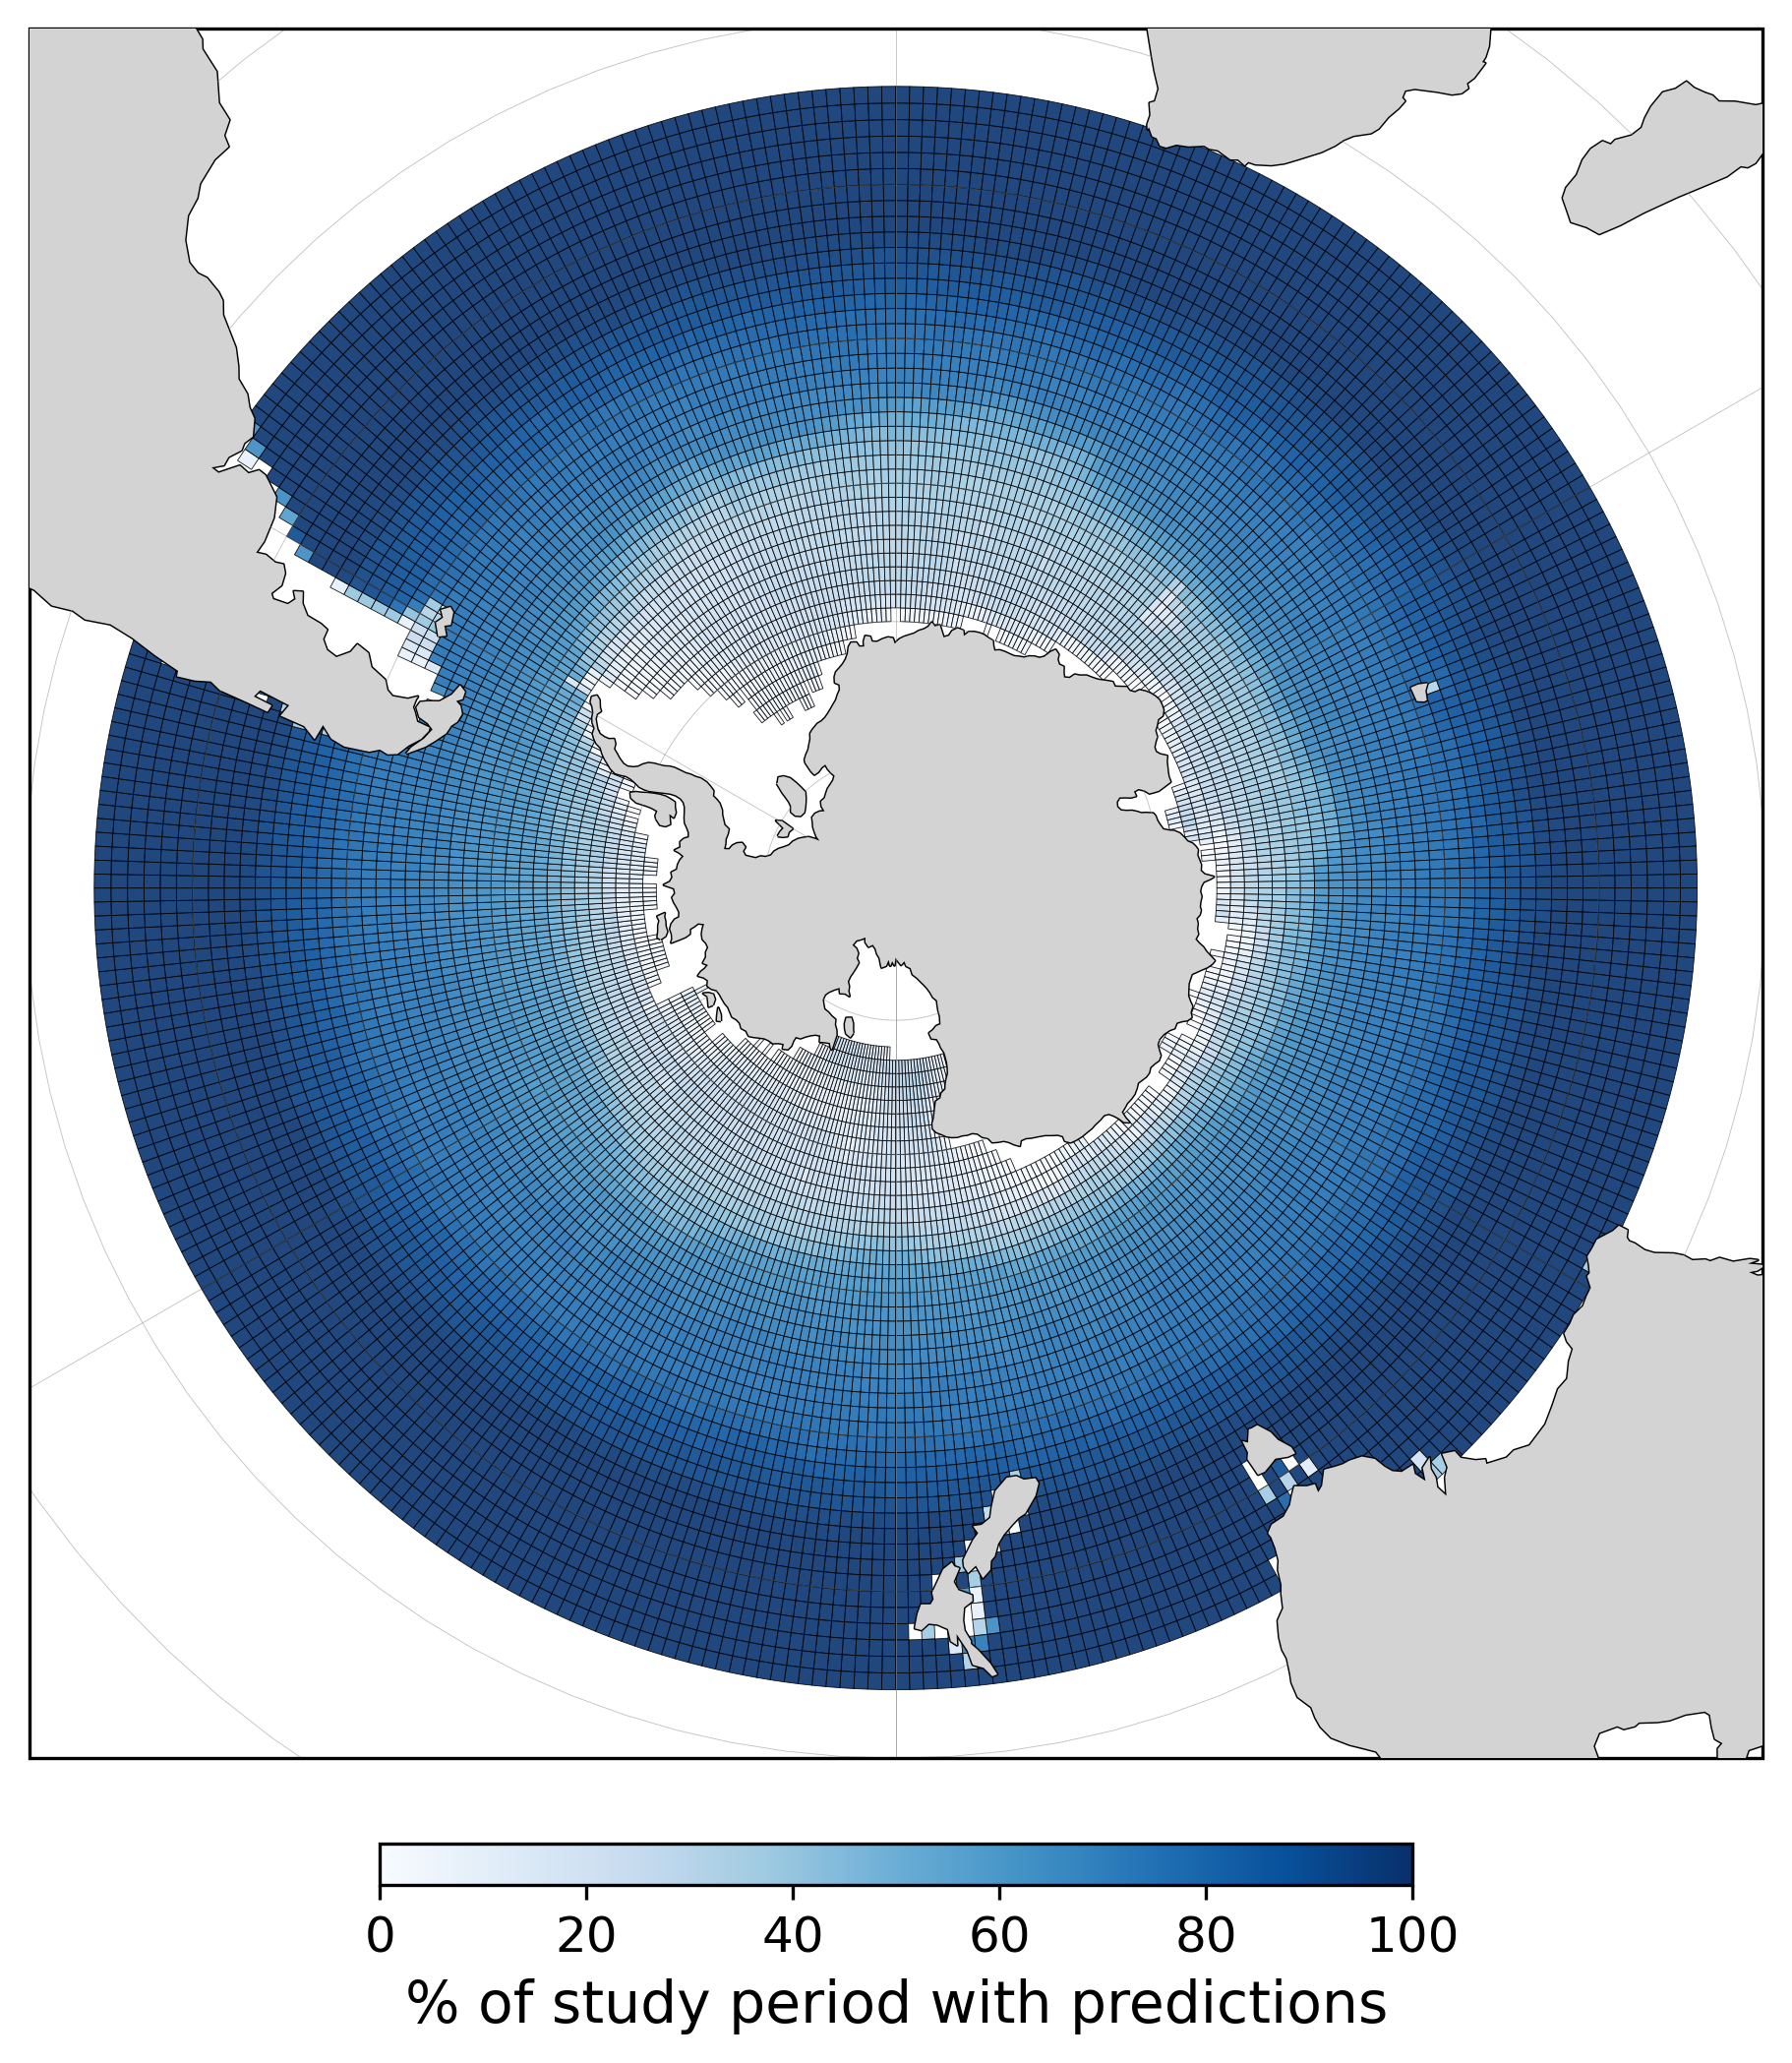

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# === LOAD MATRIX DATA ===
matrix = pd.read_csv(
    "/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/processing_steps/ARMOR3D_TS_SouthernOcean_1997_2024_monthly_surface_SLA_RRS_CHL_PAR_WIND_CO2_ATM_MLD_COORDS.csv",
    low_memory=False
)

# === FILTER TO SOUTHERN OCEAN AND TIME RANGE ===
start_date = "2003-01-01"
end_date = "2024-12-31"

matrix = matrix[
    (matrix['latitude'] <= -35) &
    (pd.to_datetime(matrix['time']) >= start_date) &
    (pd.to_datetime(matrix['time']) <= end_date)
].dropna()

# === COVERAGE FUNCTION ===
def prepare_coverage(df, lat_col, lon_col, time_col):
    df = df.dropna(subset=[lat_col, lon_col, time_col]).copy()
    df['datetime'] = pd.to_datetime(df[time_col])
    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['latitude'] = df[lat_col].astype(int)
    df['longitude'] = df[lon_col].astype(int)
    df['year_month'] = df['datetime'].dt.to_period('M')
    unique_bins = df[['latitude', 'longitude', 'year_month']].drop_duplicates()
    grouped = unique_bins.groupby(['latitude', 'longitude']).size().reset_index(name='month_count')
    grouped['percent'] = 100 * grouped['month_count'] / 252
    return grouped

# === COMPUTE MODEL COVERAGE ===
matrix_coverage = prepare_coverage(matrix, 'latitude', 'longitude', 'time')

# === PLOT ONLY PANEL D ===
fig = plt.figure(figsize=(7, 7), dpi=300)
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())

# Colormap for percent coverage
norm = mcolors.Normalize(vmin=0, vmax=100)
cmap = plt.cm.Blues
sm = ScalarMappable(norm=norm, cmap=cmap)

for _, row in matrix_coverage.iterrows():
    rect = Rectangle(
        (row['longitude'], row['latitude']), 1, 1,
        facecolor=cmap(norm(row['percent'])),
        edgecolor='k',
        linewidth=0.2,
        transform=ccrs.PlateCarree(),
        alpha=0.9
    )
    ax.add_patch(rect)

ax.coastlines(resolution='110m', linewidth=0.7)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=12)
ax.gridlines(draw_labels=False, linewidth=0.2, color='gray', alpha=0.5)

# Add colorbar
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cb.set_label("% of study period with predictions", fontsize=14)
cb.ax.tick_params(labelsize=12)

# Save figure
plt.tight_layout(rect=[0, 0.12, 1, 1])
fig.savefig("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/model_matrix_coverage_percent.png", dpi=300, bbox_inches='tight')
plt.show()


#### _____________________________________________________________________________________________________________________
#### _____________________________________________________________________________________________________________________

In [ ]:
import pandas as pd
predictions_socat = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/matrix_predictions/pco2_prediction_matrix_SOCAT_only_models.csv")
predictions_floats = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/matrix_predictions/pco2_prediction_matrix_FLOATS_only_models.csv")
predictions_floats_low = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/matrix_predictions/pco2_prediction_matrix_FLOATS_only_minus_unc_models.csv")
predictions_floats_high = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/matrix_predictions/pco2_prediction_matrix_FLOATS_only_plus_unc_models.csv")
predictions_socat_and_floats = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/matrix_predictions/pco2_prediction_matrix_SOCAT_AND_FLOATS_models.csv")
socat_df = pd.read_csv('/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/MODEL_SOCAT_ONLY_OBS/processing_steps/SOCATv2025_SO_clean_SLA_RRS_CHL_WIND_PAR_CO2ATM_MLD_COORDS_PCO2.csv', low_memory=False)

In [ ]:
predictions_socat

In [ ]:
socat_df

In [ ]:
socat_df_low = socat_df.copy()
socat_df_low['pco2'] = socat_df_low['pco2'] - 4

socat_df_high = socat_df.copy()
socat_df_high['pco2'] = socat_df_high['pco2'] + 4


In [ ]:
# --- Column Renaming and Inputs ---
rename_map = {
    'sst_degC': 'temperature'
}

socat_df.rename(columns=rename_map, inplace=True)
socat_df_low.rename(columns=rename_map, inplace=True)
socat_df_high.rename(columns=rename_map, inplace=True)


In [ ]:
uncer = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/data/BGC-ARGO/BGC-ARGO_mean_0-10m_surface_pco2_all_profiles_with_uncertainty.csv")
floats_df = pd.read_csv('/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/MODEL_FLOATS/processing_steps/BGC-ARGO_mean_0-10m_surface_pco2_all_profiles_US_pco2_SLA_RRS_CHL_PAR_WIND_CO2ATM_MLD_COORDS.csv', low_memory=False)

# Ensure both datetimes are real datetime objects (not strings)
uncer['datetime'] = pd.to_datetime(uncer['datetime'])
floats_df['datetime'] = pd.to_datetime(floats_df['datetime'])

# Round to nearest second (or adjust if higher precision is needed)
uncer['datetime'] = uncer['datetime'].dt.round('1s')
floats_df['datetime'] = floats_df['datetime'].dt.round('1s')

# Round lat/lon to improve merge success rate
uncer['latitude'] = uncer['latitude'].round(4)
uncer['longitude'] = uncer['longitude'].round(4)
floats_df['latitude'] = floats_df['latitude'].round(4)
floats_df['longitude'] = floats_df['longitude'].round(4)

# Define keys for merge
merge_keys = ['platform_number', 'cycle_number']

# Perform merge
floats_df = floats_df.merge(
    uncer[merge_keys + ['pco2_uncertainty']],
    on=merge_keys,
    how='left'
)

# Print match stats
total_rows = len(floats_df)
matched_rows = floats_df['pco2_uncertainty'].notna().sum()
match_pct = (matched_rows / total_rows) * 100

print(f"pCO₂ uncertainty matched for {matched_rows:,} out of {total_rows:,} rows ({match_pct:.2f}%)")

In [ ]:
# Make copies to preserve original data
floats_df_low = floats_df.copy()
floats_df_high = floats_df.copy()

# Subtract and add the uncertainty
floats_df_low['pco2'] = floats_df_low['pco2'] - floats_df_low['pco2_uncertainty']
floats_df_high['pco2'] = floats_df_high['pco2'] + floats_df_high['pco2_uncertainty']

print("Created floats_df_low and floats_df_high with adjusted pCO₂ values.")


In [ ]:
# Combine SOCAT and FLOATS observations
combined_df = pd.concat([socat_df, floats_df], ignore_index=True)

In [ ]:
# Fill missing pco2_uncertainty with 4 where it's SOCAT data
# Condition: pco2_uncertainty is NaN AND expocode is NOT NaN (i.e., it's SOCAT)
combined_df['pco2_uncertainty'] = combined_df.apply(
    lambda row: 4.0 if pd.isna(row['pco2_uncertainty']) and pd.notna(row['expocode']) else row['pco2_uncertainty'],
    axis=1
)

print(f"Filled SOCAT uncertainty with 4.0 where missing. Total missing after fill: {combined_df['pco2_uncertainty'].isna().sum()}")

# Create low and high DataFrames
combined_df_low = combined_df.copy()
combined_df_high = combined_df.copy()

combined_df_low['pco2'] = combined_df_low['pco2'] - combined_df_low['pco2_uncertainty']
combined_df_high['pco2'] = combined_df_high['pco2'] + combined_df_high['pco2_uncertainty']

print("Created combined_df_low and combined_df_high with uncertainty-adjusted pCO₂ values.")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyseaflux

# === Define flux calculation functions ===
def compute_co2_flux_from_predictions(df):
    wind_speed = df["wind_speed"].values
    temp_C = df["temperature"].values
    salinity = df["salinity"].values
    pCO2_sw = df["ensemble_pco2_pred"].values
    pCO2_air = df["atm_co2"].values
    pres_hPa = df["air_pressure_hpa"].values if "air_pressure_hpa" in df else 1013.25

    k_w_cmhr = pyseaflux.gas_transfer_velocity.k_Ho06(wind_speed, temp_C)
    CO2_flux_mol_m2_day = pyseaflux.flux_calculations.flux_bulk(
        temp_C, salinity, pCO2_sw, pCO2_air, pres_hPa, k_w_cmhr
    )
    return CO2_flux_mol_m2_day * 12.01  # Convert to gC

def compute_co2_flux_from_obs(df):
    wind_speed = df["wind_speed"].values
    temp_C = df["temperature"].values
    salinity = df["salinity"].values
    pCO2_sw = df["pco2"].values
    pCO2_air = df["atm_co2"].values
    pres_hPa = df["air_pressure_hpa"].values if "air_pressure_hpa" in df else 1013.25

    k_w_cmhr = pyseaflux.gas_transfer_velocity.k_Ho06(wind_speed, temp_C)
    CO2_flux_mol_m2_day = pyseaflux.flux_calculations.flux_bulk(
        temp_C, salinity, pCO2_sw, pCO2_air, pres_hPa, k_w_cmhr
    )
    return CO2_flux_mol_m2_day * 12.01


# === Bin to 1° grid function ===
def bin_flux_to_grid(df, lat_col='latitude', lon_col='longitude', year_col='year', flux_col='flux_gC_m2_month'):
    df = df.copy()
    df['lat_bin'] = df[lat_col].astype(int)
    df['lon_bin'] = df[lon_col].astype(int)
    binned = df.groupby(['lat_bin', 'lon_bin', df[year_col]])[flux_col].mean().reset_index()
    binned.rename(columns={flux_col: 'mean_flux'}, inplace=True)
    return binned

# === Compute flux for observations (standard + low/high variants) ===
for df_name, df in {
    "socat_df": socat_df,
    "socat_df_low": socat_df_low,
    "socat_df_high": socat_df_high,
    "floats_df": floats_df,
    "floats_df_low": floats_df_low,
    "floats_df_high": floats_df_high,
    "combined_df": combined_df,
    "combined_df_low": combined_df_low,
    "combined_df_high": combined_df_high,
}.items():
    df['datetime'] = pd.to_datetime(df['date']) if 'date' in df.columns else pd.to_datetime(df['datetime'])
    df['flux_gC_m2_day'] = compute_co2_flux_from_obs(df)
    df['flux_gC_m2_month'] = df['flux_gC_m2_day'] * df['datetime'].dt.days_in_month
    df['year'] = df['datetime'].dt.year
    print(f"Processed: {df_name} — {len(df)} rows")


# === Bin to 1x1 grid ===
socat_binned_flux = bin_flux_to_grid(socat_df, flux_col='flux_gC_m2_month')
floats_binned_flux = bin_flux_to_grid(floats_df, flux_col='flux_gC_m2_month')
combined_binned_flux = bin_flux_to_grid(combined_df, flux_col='flux_gC_m2_month')
socat_binned_flux_low = bin_flux_to_grid(socat_df_low, flux_col='flux_gC_m2_month')
socat_binned_flux_high = bin_flux_to_grid(socat_df_high, flux_col='flux_gC_m2_month')
floats_binned_flux_low = bin_flux_to_grid(floats_df_low, flux_col='flux_gC_m2_month')
floats_binned_flux_high = bin_flux_to_grid(floats_df_high, flux_col='flux_gC_m2_month')
combined_binned_flux_low = bin_flux_to_grid(combined_df_low, flux_col='flux_gC_m2_month')
combined_binned_flux_high = bin_flux_to_grid(combined_df_high, flux_col='flux_gC_m2_month')

# === Compute spatial yearly means ===
def compute_spatial_yearly_means(binned_df, label):
    df = binned_df.groupby('year')['mean_flux'].mean().reset_index()
    df.rename(columns={'mean_flux': label}, inplace=True)
    return df

summary_socat = compute_spatial_yearly_means(socat_binned_flux, 'SOCAT')
summary_floats = compute_spatial_yearly_means(floats_binned_flux, 'Floats')
summary_combined = compute_spatial_yearly_means(combined_binned_flux, 'SOCAT+Floats')
summary_socat_low = compute_spatial_yearly_means(socat_binned_flux_low, 'SOCAT_low')
summary_socat_high = compute_spatial_yearly_means(socat_binned_flux_high, 'SOCAT_high')
summary_floats_low = compute_spatial_yearly_means(floats_binned_flux_low, 'Floats_low')
summary_floats_high = compute_spatial_yearly_means(floats_binned_flux_high, 'Floats_high')
summary_combined_low = compute_spatial_yearly_means(combined_binned_flux_low, 'SOCAT+Floats_low')
summary_combined_high = compute_spatial_yearly_means(combined_binned_flux_high, 'SOCAT+Floats_high')

# === Compute fluxes for predictions ===
def process_prediction_flux(df, label):
    df['time'] = pd.to_datetime(df['time'])
    df['flux_gC_m2_day'] = compute_co2_flux_from_predictions(df)
    df['flux_gC_m2_month'] = df['flux_gC_m2_day'] * df['time'].dt.days_in_month
    df['year'] = df['time'].dt.year
    df['lat_bin'] = df['latitude'].astype(int)
    df['lon_bin'] = df['longitude'].astype(int)
  
    binned = df.groupby(['lat_bin', 'lon_bin', 'year'])['flux_gC_m2_month'].mean().reset_index()

    binned.rename(columns={'flux_gC_m2_month': 'mean_flux'}, inplace=True)
    summary = binned.groupby('year')['mean_flux'].mean().reset_index()
    summary.rename(columns={'mean_flux': label}, inplace=True)
    return summary

summary_preds_socat = process_prediction_flux(predictions_socat, 'SOCAT_predictions')
summary_preds_floats = process_prediction_flux(predictions_floats, 'FLOATS_predictions')
summary_preds_floats_low = process_prediction_flux(predictions_floats_low, 'FLOATS_predictions_low')
summary_preds_floats_high = process_prediction_flux(predictions_floats_high, 'FLOATS_predictions_high')
summary_preds_socat_and_floats = process_prediction_flux(predictions_socat_and_floats, 'SOCAT_AND_FLOATS_predictions')


# === Merge all summaries ===
yearly_flux_summary = summary_preds_socat \
    .merge(summary_socat, on='year', how='outer') \
    .merge(summary_preds_floats, on='year', how='outer') \
    .merge(summary_preds_floats_low, on='year', how='outer') \
    .merge(summary_preds_floats_high, on='year', how='outer') \
    .merge(summary_preds_socat_and_floats, on='year', how='outer') \
    .merge(summary_floats, on='year', how='outer') \
    .merge(summary_combined, on='year', how='outer') \
    .merge(summary_socat_low, on='year', how='outer') \
    .merge(summary_socat_high, on='year', how='outer') \
    .merge(summary_floats_low, on='year', how='outer') \
    .merge(summary_floats_high, on='year', how='outer') \
    .merge(summary_combined_low, on='year', how='outer') \
    .merge(summary_combined_high, on='year', how='outer') \
    .sort_values('year')

# Final cleanup
#yearly_flux_summary.loc[yearly_flux_summary['Floats'].isna(), 'SOCAT+Floats'] = np.nan
yearly_flux_summary.loc[yearly_flux_summary['year'] < 2003, 'FLOATS_predictions'] = np.nan
#yearly_flux_summary.loc[yearly_flux_summary['year'] < 2003, 'SOCAT+Floats_low'] = np.nan
#yearly_flux_summary.loc[yearly_flux_summary['year'] < 2003, 'SOCAT+Floats_high'] = np.nan
yearly_flux_summary.loc[yearly_flux_summary['year'] < 2003, 'FLOATS_predictions_low'] = np.nan


In [ ]:
# Convert to gC·m⁻²·yr⁻¹ — Grams of carbon per square meter per year
for col in yearly_flux_summary.columns:
    if col != 'year':
        yearly_flux_summary[col] *= 12

yearly_flux_summary

In [ ]:
# === Plotting ===
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 10), dpi=300, sharex=True, gridspec_kw={'hspace': 0.15}
)

# --- Top Plot: Observations ---
line1, = ax1.plot(yearly_flux_summary['year'], yearly_flux_summary['SOCAT'],
                  label='SOCATv2025', c='k', zorder=2)
line3, = ax1.plot(yearly_flux_summary['year'], yearly_flux_summary['Floats'],
                  label='BGC-Argo floats', c='tab:blue', zorder=2)
line5, = ax1.plot(yearly_flux_summary['year'], yearly_flux_summary['SOCAT+Floats'],
                  label='SOCATv2025+BGC-Argo floats', c='#A4D4B4', zorder=2)

# Add uncertainty bands
ax1.fill_between(
    yearly_flux_summary['year'],
    yearly_flux_summary['SOCAT_low'],
    yearly_flux_summary['SOCAT_high'],
    color='k', alpha=0.15, zorder=1
)
ax1.fill_between(
    yearly_flux_summary['year'],
    yearly_flux_summary['Floats_low'],
    yearly_flux_summary['Floats_high'],
    color='tab:blue', alpha=0.15, zorder=1
)
ax1.fill_between(
    yearly_flux_summary['year'],
    yearly_flux_summary['SOCAT+Floats_low'],
    yearly_flux_summary['SOCAT+Floats_high'],
    color='#A4D4B4', alpha=0.3, zorder=1
)

#ax1.legend(loc='lower left', ncol=3)
ax1.set_ylabel(r'Observed CO$_2$ flux (g C m$^{-2}$ yr$^{-1}$)')
ax1.set_xlim(1997, 2024)
ax1.set_ylim(-60, 20)
ax1.axhline(y=0, c='k', lw=0.8)
ax1.grid(True)
ax1.axvspan(1997, 2003, color='lightgray', alpha=0.5, zorder=1)

# --- Bottom Plot: Predictions ---
line2, = ax2.plot(yearly_flux_summary['year'], yearly_flux_summary['SOCAT_predictions'],
                  label=r'Model$_{\mathrm{SOCATv2025}}$', linestyle='--', c='k', zorder=2)
line4, = ax2.plot(yearly_flux_summary['year'], yearly_flux_summary['FLOATS_predictions'],
                  label=r'Model$_{\mathrm{BGC-Argo\ floats}}$', linestyle='--', c='tab:blue', zorder=2)

# Add fill_between for FLOATS prediction uncertainty
ax2.fill_between(
    yearly_flux_summary['year'],
    yearly_flux_summary['FLOATS_predictions_low'],
    yearly_flux_summary['FLOATS_predictions_high'],
    color='tab:blue',
    alpha=0.15,
    zorder=1,
    label='_nolegend_'
)


line6, = ax2.plot(yearly_flux_summary['year'], yearly_flux_summary['SOCAT_AND_FLOATS_predictions'],
                  label=r'Model$_{\mathrm{SOCATv2025+BGC-Argo\ floats}}$', linestyle='--', c='#A4D4B4', zorder=2)

#ax2.legend(loc='lower left', ncol=3)
ax2.set_xlabel('Year')
ax2.set_ylabel(r'Modeled CO$_2$ flux (g C m$^{-2}$ yr$^{-1}$)')
ax2.set_xlim(1997, 2024)
ax2.set_xticks([1997, 2000, 2005, 2010, 2015, 2020, 2024])
ax2.set_ylim(-60, 20)
ax2.axhline(y=0, c='k', lw=0.8)
ax2.grid(True)
ax2.axvspan(1997, 2003, color='lightgray', alpha=0.5, zorder=1)

# Add subplot labels
ax1.text(0, 1.06, 'a)', transform=ax1.transAxes,
         fontsize=12, va='top', ha='left')
ax2.text(0, 1.06, 'b)', transform=ax2.transAxes,
         fontsize=12, va='top', ha='left')

# Define legend items in desired order
handles = [line1, line2, line3, line4, line5, line6]
labels = [
    'SOCATv2025',
    r'Model$_{\mathrm{SOCATv2025}}$',
    'BGC-Argo floats',
    r'Model$_{\mathrm{BGC-Argo\ floats}}$',
    'SOCATv2025+BGC-Argo floats',
    r'Model$_{\mathrm{SOCATv2025+BGC-Argo\ floats}}$'
]


fig.legend(handles, labels,
           loc='lower center',
           ncol=3,
           frameon=False,
           fontsize=10,
           bbox_to_anchor=(0.52, -0.02))

fig.tight_layout(rect=[0, 0.04, 1, 1])  # adjust bottom margin for legend

# Save & Show
fig.savefig("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/figs/main_result_obs_vs_models.png",
            dpi=300, bbox_inches='tight')
plt.show()

“If we naïvely scaled this flux to the whole Southern Ocean, we’d get X Pg C/yr — but this varies depending on coverage.”

These are hypothetical full-SO fluxes assuming each method’s observed flux density applies to the entire Southern Ocean.

This gives a powerful result:

    “Even though SOCAT and FLOATS cover different regions, if you extrapolated their flux densities to the whole Southern Ocean, you get very different uptake values.”

In [ ]:
OCEAN_AREA_M2 = 7e13
for col in yearly_flux_summary.columns:
    if col != 'year':
        yearly_flux_summary[col + '_PgC_yr'] = yearly_flux_summary[col] * OCEAN_AREA_M2 / 1e15


In [ ]:
yearly_flux_summary

In [ ]:
# Identify all naïvely scaled Pg C/yr columns
pgcyr_cols = [col for col in yearly_flux_summary.columns if col.endswith('_PgC_yr')]

# Filter the dataframe to only include years from 2003 to 2024
filtered_df = yearly_flux_summary[(yearly_flux_summary['year'] >= 2003) & (yearly_flux_summary['year'] <= 2024)]

# Compute mean uptake across filtered years for each method (NaNs ignored)
mean_uptake = filtered_df[pgcyr_cols].mean()

# Sort alphabetically by method name
mean_uptake = mean_uptake.sort_index()

# Display results with 2 decimal places
print("Mean Southern Ocean CO₂ uptake (Pg C/yr), naive full-area scaling (2003–2024):")
for label, value in mean_uptake.items():
    print(f"{label}: {value:.2f}")


### Comparison with atmospheric inversion fluxes and interior ocean

In [ ]:
# --- imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyseaflux

# =========================
# 1) LOAD DATA (your paths)
# =========================
predictions_socat = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/matrix_predictions/pco2_prediction_matrix_SOCAT_only_models.csv")
predictions_floats = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/matrix_predictions/pco2_prediction_matrix_FLOATS_only_models.csv")
predictions_floats_low = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/matrix_predictions/pco2_prediction_matrix_FLOATS_only_minus_unc_models.csv")
predictions_floats_high = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/matrix_predictions/pco2_prediction_matrix_FLOATS_only_plus_unc_models.csv")
predictions_socat_and_floats = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/matrix_predictions/pco2_prediction_matrix_SOCAT_AND_FLOATS_models.csv")

socat_df = pd.read_csv('/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/MODEL_SOCAT_ONLY_OBS/processing_steps/SOCATv2025_SO_clean_SLA_RRS_CHL_WIND_PAR_CO2ATM_MLD_COORDS_PCO2.csv', low_memory=False)

# Uncertainty variants for SOCAT (±4 µatm)
socat_df_low = socat_df.copy()
socat_df_low['pco2'] = socat_df_low['pco2'] - 4
socat_df_high = socat_df.copy()
socat_df_high['pco2'] = socat_df_high['pco2'] + 4

# Column rename for flux calc
socat_df.rename(columns={'sst_degC': 'temperature'}, inplace=True)
socat_df_low.rename(columns={'sst_degC': 'temperature'}, inplace=True)
socat_df_high.rename(columns={'sst_degC': 'temperature'}, inplace=True)

# Floats + per-profile pCO2 uncertainty
uncer = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/data/BGC-ARGO/BGC-ARGO_mean_0-10m_surface_pco2_all_profiles_with_uncertainty.csv")
floats_df = pd.read_csv('/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/MODEL_FLOATS/processing_steps/BGC-ARGO_mean_0-10m_surface_pco2_all_profiles_US_pco2_SLA_RRS_CHL_PAR_WIND_CO2ATM_MLD_COORDS.csv', low_memory=False)

# Merge uncertainty onto floats
uncer['datetime'] = pd.to_datetime(uncer['datetime']).dt.round('1s')
floats_df['datetime'] = pd.to_datetime(floats_df['datetime']).dt.round('1s')
uncer['latitude'] = uncer['latitude'].round(4)
uncer['longitude'] = uncer['longitude'].round(4)
floats_df['latitude'] = floats_df['latitude'].round(4)
floats_df['longitude'] = floats_df['longitude'].round(4)
merge_keys = ['platform_number', 'cycle_number']
floats_df = floats_df.merge(uncer[merge_keys + ['pco2_uncertainty']], on=merge_keys, how='left')

print(f"pCO₂ uncertainty matched for {floats_df['pco2_uncertainty'].notna().sum():,} / {len(floats_df):,} rows")

# Build ±unc variants for floats
floats_df_low = floats_df.copy()
floats_df_high = floats_df.copy()
floats_df_low['pco2']  = floats_df_low['pco2']  - floats_df_low['pco2_uncertainty']
floats_df_high['pco2'] = floats_df_high['pco2'] + floats_df_high['pco2_uncertainty']
print("Created floats_df_low and floats_df_high with adjusted pCO₂ values.")

# Combined obs + fill SOCAT uncertainty with 4 µatm
combined_df = pd.concat([socat_df, floats_df], ignore_index=True)
combined_df['pco2_uncertainty'] = combined_df.apply(
    lambda r: 4.0 if pd.isna(r.get('pco2_uncertainty')) and pd.notna(r.get('expocode')) else r.get('pco2_uncertainty'),
    axis=1
)
print(f"Filled SOCAT uncertainty where missing. Remaining NaNs: {combined_df['pco2_uncertainty'].isna().sum()}")

combined_df_low = combined_df.copy()
combined_df_high = combined_df.copy()
combined_df_low['pco2']  = combined_df_low['pco2']  - combined_df_low['pco2_uncertainty']
combined_df_high['pco2'] = combined_df_high['pco2'] + combined_df_high['pco2_uncertainty']
print("Created combined_df_low/high with uncertainty-adjusted pCO₂.")

# =====================================
# 2) FLUX FUNCTIONS (obs & predictions)
# =====================================
def compute_co2_flux_from_predictions(df):
    wind_speed = df["wind_speed"].values
    temp_C     = df["temperature"].values
    salinity   = df["salinity"].values
    pCO2_sw    = df["ensemble_pco2_pred"].values
    pCO2_air   = df["atm_co2"].values
    pres_hPa   = df["air_pressure_hpa"].values if "air_pressure_hpa" in df else 1013.25
    k_w_cmhr   = pyseaflux.gas_transfer_velocity.k_Ho06(wind_speed, temp_C)
    flux_mol_m2_day = pyseaflux.flux_calculations.flux_bulk(temp_C, salinity, pCO2_sw, pCO2_air, pres_hPa, k_w_cmhr)
    return flux_mol_m2_day * 12.01  # g C m^-2 day^-1

def compute_co2_flux_from_obs(df):
    wind_speed = df["wind_speed"].values
    temp_C     = df["temperature"].values
    salinity   = df["salinity"].values
    pCO2_sw    = df["pco2"].values
    pCO2_air   = df["atm_co2"].values
    pres_hPa   = df["air_pressure_hpa"].values if "air_pressure_hpa" in df else 1013.25
    k_w_cmhr   = pyseaflux.gas_transfer_velocity.k_Ho06(wind_speed, temp_C)
    flux_mol_m2_day = pyseaflux.flux_calculations.flux_bulk(temp_C, salinity, pCO2_sw, pCO2_air, pres_hPa, k_w_cmhr)
    return flux_mol_m2_day * 12.01  # g C m^-2 day^-1

# ============================================
# 3) BIN TO 1° GRID (kept as in your pipeline)
# ============================================
def bin_flux_to_grid(df, lat_col='latitude', lon_col='longitude', year_col='year', flux_col='flux_gC_m2_month'):
    df = df.copy()
    df['lat_bin'] = df[lat_col].astype(int)
    df['lon_bin'] = df[lon_col].astype(int)
    binned = df.groupby(['lat_bin', 'lon_bin', df[year_col]])[flux_col].mean().reset_index()
    binned.rename(columns={flux_col: 'mean_flux'}, inplace=True)
    return binned

# ======================================================
# 4) COMPUTE MONTHLY FLUX, THEN BIN (OBS incl. variants)
# ======================================================
for df_name, df in {
    "socat_df": socat_df,
    "socat_df_low": socat_df_low,
    "socat_df_high": socat_df_high,
    "floats_df": floats_df,
    "floats_df_low": floats_df_low,
    "floats_df_high": floats_df_high,
    "combined_df": combined_df,
    "combined_df_low": combined_df_low,
    "combined_df_high": combined_df_high,
}.items():
    # datetime column differs by dataset
    df['datetime'] = pd.to_datetime(df['date']) if 'date' in df.columns else pd.to_datetime(df['datetime'])
    df['flux_gC_m2_day']   = compute_co2_flux_from_obs(df)
    df['flux_gC_m2_month'] = df['flux_gC_m2_day'] * df['datetime'].dt.days_in_month
    df['year'] = df['datetime'].dt.year
    print(f"Processed: {df_name} — {len(df):,} rows")

# Bin all obs variants
socat_binned_flux         = bin_flux_to_grid(socat_df,         flux_col='flux_gC_m2_month')
floats_binned_flux        = bin_flux_to_grid(floats_df,        flux_col='flux_gC_m2_month')
combined_binned_flux      = bin_flux_to_grid(combined_df,      flux_col='flux_gC_m2_month')
socat_binned_flux_low     = bin_flux_to_grid(socat_df_low,     flux_col='flux_gC_m2_month')
socat_binned_flux_high    = bin_flux_to_grid(socat_df_high,    flux_col='flux_gC_m2_month')
floats_binned_flux_low    = bin_flux_to_grid(floats_df_low,    flux_col='flux_gC_m2_month')
floats_binned_flux_high   = bin_flux_to_grid(floats_df_high,   flux_col='flux_gC_m2_month')
combined_binned_flux_low  = bin_flux_to_grid(combined_df_low,  flux_col='flux_gC_m2_month')
combined_binned_flux_high = bin_flux_to_grid(combined_df_high, flux_col='flux_gC_m2_month')

# ======================================
# 5) AREA WEIGHTS + AREA-WEIGHTED MEANS
# ======================================
R = 6371000.0
deg2rad = np.pi / 180.0
# lat_bin is floor(lat) → integers …,-89,…,+89
lat_centers = np.arange(-89.5, 90.5, 1.0)[:-1]
band_areas = (2*np.pi*R**2) * (np.sin((lat_centers+0.5)*deg2rad) - np.sin((lat_centers-0.5)*deg2rad))
cell_area_by_lat = pd.Series(band_areas/360.0, index=np.arange(-89, 90, 1))  # m^2 per 1°x1° cell

def add_area_weights(df, lat_col='lat_bin'):
    return df.merge(cell_area_by_lat.rename('cell_area_m2'),
                    left_on=lat_col, right_index=True, how='left')

def area_weighted_year_mean(binned_df, value_col='mean_flux'):
    # returns area-weighted mean flux (g C m^-2 month-equivalent); multiply by 12 later for g C m^-2 yr^-1
    df = add_area_weights(binned_df)
    out = (
        df.groupby('year')
          .apply(lambda d: (d[value_col]*d['cell_area_m2']).sum() / d['cell_area_m2'].sum())
          .reset_index(name='aw_mean_flux')
    )
    return out

def area_integrated_year_total(binned_df, value_col='mean_flux'):
    # returns integrated total over *covered* area (Pg C yr^-1) after month→year scaling
    df = add_area_weights(binned_df)
    out = (
        df.groupby('year')
          .apply(lambda d: (d[value_col]*12.0 * d['cell_area_m2']).sum() / 1e15)
          .reset_index(name='PgCyr_over_covered')
    )
    return out

# Area-weighted yearly means (OBS)
summary_socat         = area_weighted_year_mean(socat_binned_flux      ).rename(columns={'aw_mean_flux':'SOCAT'})
summary_floats        = area_weighted_year_mean(floats_binned_flux     ).rename(columns={'aw_mean_flux':'Floats'})
summary_combined      = area_weighted_year_mean(combined_binned_flux   ).rename(columns={'aw_mean_flux':'SOCAT+Floats'})

summary_socat_low     = area_weighted_year_mean(socat_binned_flux_low  ).rename(columns={'aw_mean_flux':'SOCAT_low'})
summary_socat_high    = area_weighted_year_mean(socat_binned_flux_high ).rename(columns={'aw_mean_flux':'SOCAT_high'})
summary_floats_low    = area_weighted_year_mean(floats_binned_flux_low ).rename(columns={'aw_mean_flux':'Floats_low'})
summary_floats_high   = area_weighted_year_mean(floats_binned_flux_high).rename(columns={'aw_mean_flux':'Floats_high'})
summary_combined_low  = area_weighted_year_mean(combined_binned_flux_low ).rename(columns={'aw_mean_flux':'SOCAT+Floats_low'})
summary_combined_high = area_weighted_year_mean(combined_binned_flux_high).rename(columns={'aw_mean_flux':'SOCAT+Floats_high'})

# (Optional) integrated totals over covered area (Pg C/yr) — handy for tables
socat_tot_covered    = area_integrated_year_total(socat_binned_flux     ).rename(columns={'PgCyr_over_covered':'SOCAT_PgCyr_cov'})
floats_tot_covered   = area_integrated_year_total(floats_binned_flux    ).rename(columns={'PgCyr_over_covered':'Floats_PgCyr_cov'})
combined_tot_covered = area_integrated_year_total(combined_binned_flux  ).rename(columns={'PgCyr_over_covered':'SOCAT+Floats_PgCyr_cov'})

# ======================================================
# 6) PREDICTIONS → BIN → AREA-WEIGHTED YEARLY MEAN
# ======================================================
def process_prediction_flux(df, label):
    df = df.copy()
    df['time'] = pd.to_datetime(df['time'])
    df['flux_gC_m2_day']   = compute_co2_flux_from_predictions(df)
    df['flux_gC_m2_month'] = df['flux_gC_m2_day'] * df['time'].dt.days_in_month
    df['year'] = df['time'].dt.year
    df['lat_bin'] = df['latitude'].astype(int)
    df['lon_bin'] = df['longitude'].astype(int)
    binned = (df.groupby(['lat_bin','lon_bin','year'])['flux_gC_m2_month']
                .mean().reset_index()
                .rename(columns={'flux_gC_m2_month':'mean_flux'}))
    aw = area_weighted_year_mean(binned, value_col='mean_flux')
    aw.rename(columns={'aw_mean_flux': label}, inplace=True)
    return aw

summary_preds_socat             = process_prediction_flux(predictions_socat,            'SOCAT_predictions')
summary_preds_floats            = process_prediction_flux(predictions_floats,           'FLOATS_predictions')
summary_preds_floats_low        = process_prediction_flux(predictions_floats_low,       'FLOATS_predictions_low')
summary_preds_floats_high       = process_prediction_flux(predictions_floats_high,      'FLOATS_predictions_high')
summary_preds_socat_and_floats  = process_prediction_flux(predictions_socat_and_floats, 'SOCAT_AND_FLOATS_predictions')

# ==========================
# 7) MERGE + FINAL CLEANUPS
# ==========================
yearly_flux_summary = (
    summary_preds_socat
      .merge(summary_socat, on='year', how='outer')
      .merge(summary_preds_floats, on='year', how='outer')
      .merge(summary_preds_floats_low, on='year', how='outer')
      .merge(summary_preds_floats_high, on='year', how='outer')
      .merge(summary_preds_socat_and_floats, on='year', how='outer')
      .merge(summary_floats, on='year', how='outer')
      .merge(summary_combined, on='year', how='outer')
      .merge(summary_socat_low, on='year', how='outer')
      .merge(summary_socat_high, on='year', how='outer')
      .merge(summary_floats_low, on='year', how='outer')
      .merge(summary_floats_high, on='year', how='outer')
      .merge(summary_combined_low, on='year', how='outer')
      .merge(summary_combined_high, on='year', how='outer')
      .sort_values('year')
)

# No floats predictions pre-2003
yearly_flux_summary.loc[yearly_flux_summary['year'] < 2003, 'FLOATS_predictions'] = np.nan
yearly_flux_summary.loc[yearly_flux_summary['year'] < 2003, 'FLOATS_predictions_low'] = np.nan

# Convert monthly-equivalent g C m^-2 to annual g C m^-2 yr^-1
for col in yearly_flux_summary.columns:
    if col != 'year':
        yearly_flux_summary[col] = yearly_flux_summary[col] * 12.0

# =================
# 8) PLOTTING (Fig)
# =================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), dpi=300, sharex=True, gridspec_kw={'hspace': 0.15})

# Observations
line1, = ax1.plot(yearly_flux_summary['year'], yearly_flux_summary['SOCAT'],           label='SOCATv2025',                    c='k', zorder=2)
line3, = ax1.plot(yearly_flux_summary['year'], yearly_flux_summary['Floats'],          label='BGC-Argo floats',               c='tab:blue', zorder=2)
line5, = ax1.plot(yearly_flux_summary['year'], yearly_flux_summary['SOCAT+Floats'],    label='SOCATv2025+BGC-Argo floats',    c='#A4D4B4', zorder=2)

ax1.fill_between(yearly_flux_summary['year'], yearly_flux_summary['SOCAT_low'],         yearly_flux_summary['SOCAT_high'],         color='k', alpha=0.15, zorder=1)
ax1.fill_between(yearly_flux_summary['year'], yearly_flux_summary['Floats_low'],        yearly_flux_summary['Floats_high'],        color='tab:blue', alpha=0.15, zorder=1)
ax1.fill_between(yearly_flux_summary['year'], yearly_flux_summary['SOCAT+Floats_low'],  yearly_flux_summary['SOCAT+Floats_high'],  color='#A4D4B4', alpha=0.30, zorder=1)

ax1.set_ylabel(r'Observed CO$_2$ flux (g C m$^{-2}$ yr$^{-1}$)')
ax1.set_xlim(1997, 2024)
ax1.set_ylim(-60, 20)
ax1.axhline(0, c='k', lw=0.8)
ax1.grid(True)
ax1.axvspan(1997, 2003, color='lightgray', alpha=0.5, zorder=1)

# Predictions
line2, = ax2.plot(yearly_flux_summary['year'], yearly_flux_summary['SOCAT_predictions'],            label=r'Model$_{\mathrm{SOCATv2025}}$',                 linestyle='--', c='k', zorder=2)
line4, = ax2.plot(yearly_flux_summary['year'], yearly_flux_summary['FLOATS_predictions'],           label=r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$',       linestyle='--', c='tab:blue', zorder=2)
ax2.fill_between(yearly_flux_summary['year'], yearly_flux_summary['FLOATS_predictions_low'], yearly_flux_summary['FLOATS_predictions_high'], color='tab:blue', alpha=0.15, zorder=1, label='_nolegend_')
line6, = ax2.plot(yearly_flux_summary['year'], yearly_flux_summary['SOCAT_AND_FLOATS_predictions'], label=r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$',   linestyle='--', c='#A4D4B4', zorder=2)

ax2.set_xlabel('Year')
ax2.set_ylabel(r'Modeled CO$_2$ flux (g C m$^{-2}$ yr$^{-1}$)')
ax2.set_xlim(1997, 2024)
ax2.set_xticks([1997, 2000, 2005, 2010, 2015, 2020, 2024])
ax2.set_ylim(-60, 20)
ax2.axhline(0, c='k', lw=0.8)
ax2.grid(True)
ax2.axvspan(1997, 2003, color='lightgray', alpha=0.5, zorder=1)

# Labels + legend
ax1.text(0, 1.06, 'a)', transform=ax1.transAxes, fontsize=12, va='top', ha='left')
ax2.text(0, 1.06, 'b)', transform=ax2.transAxes, fontsize=12, va='top', ha='left')
handles = [line1, line2, line3, line4, line5, line6]
labels  = ['SOCATv2025', r'Model$_{\mathrm{SOCATv2025}}$', 'BGC-Argo floats', r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$', 'SOCATv2025+BGC-Argo floats', r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$']
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False, fontsize=10, bbox_to_anchor=(0.52, -0.02))
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/figs/main_result_obs_vs_models.png", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 9) OPTIONAL: Naive full-basin scaling (for your Table X flow)
# ============================================================
OCEAN_AREA_M2 = 7e13  # whole Southern Ocean area you use
scaled = yearly_flux_summary.copy()
for col in scaled.columns:
    if col != 'year':
        scaled[col + '_PgC_yr_fullarea'] = scaled[col] * OCEAN_AREA_M2 / 1e15

pgc_cols = [c for c in scaled.columns if c.endswith('_PgC_yr_fullarea')]
filtered = scaled[(scaled['year'] >= 2003) & (scaled['year'] <= 2024)]
mean_uptake = filtered[pgc_cols].mean().sort_index()

print("Mean Southern Ocean CO₂ uptake (Pg C/yr), naive full-area scaling (2003–2024):")
for label, value in mean_uptake.items():
    print(f"{label}: {value:.2f}")

# ============================================================
# 10) OPTIONAL: Covered-area totals (Pg C/yr) for obs (sanity)
# ============================================================
covered_totals = (
    socat_tot_covered
      .merge(floats_tot_covered, on='year', how='outer')
      .merge(combined_tot_covered, on='year', how='outer')
      .sort_values('year')
)
covered_totals.head()


In [ ]:
import xarray as xr
interior_anth = xr.load_dataset("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/inverse_fluxes/Gruber2019_1994-2007_v20220608/dcant_Gruber2019_1994-2007_v20220608.nc")
interior_vol = xr.load_dataset("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/inverse_fluxes/Gruber2019_1994-2007_v20220608/volume_Gruber2019_1994-2007_v20220608.nc")

In [ ]:
# ========================
# Gruber ΔCant vs. uptake
# ========================
import numpy as np
import pandas as pd
import xarray as xr

# --------- inputs this cell expects to already exist ----------
# 1) interior_anth, interior_vol : xarray Datasets you loaded earlier
#    with variables:
#      interior_anth['dcant']  (mol m^-3)
#      interior_vol['volume']  (m^3)
# 2) scaled : DataFrame you created earlier that contains full-area scaled
#    uptake time series (Pg C yr^-1), with columns named like:
#      'SOCAT_PgC_yr_fullarea', 'Floats_PgC_yr_fullarea', ...
# --------------------------------------------------------------

# ---- shortcuts to the fields we need ----
dc = interior_anth['dcant']       # mol m^-3
vol = interior_vol['volume']      # m^3
YEARS_GRUBER = 13                 # 1994–2007 inclusive

# ---- integrate ΔCant * volume to Pg C, then to mean Pg C / yr ----
def integrate_storage(dcant, volume, lat_cut=-35.0, years=YEARS_GRUBER, z_bins=None):
    """
    Sum ΔCant (mol m^-3) * volume (m^3) south of lat_cut.
    Return total Pg C over the period and mean storage rate Pg C/yr.
    Optionally do it by depth bins [(zmin,zmax), ...] in meters.
    """
    dcant, volume = xr.align(dcant, volume, join='inner')
    mask_lat = dcant['latitude'] <= lat_cut
    dcant = dcant.where(mask_lat, drop=True)
    volume = volume.where(mask_lat, drop=True)

    if z_bins is None:
        z_bins = [(None, None)]

    out = []
    for (zmin, zmax) in z_bins:
        sel  = dcant
        selV = volume
        if zmin is not None:
            sel  = sel.where(sel['z'] >= zmin, drop=True)
            selV = selV.where(selV['z'] >= zmin, drop=True)
        if zmax is not None:
            sel  = sel.where(sel['z'] <  zmax, drop=True)
            selV = selV.where(selV['z'] <  zmax, drop=True)

        mol_total = (sel * selV).sum(skipna=True)                 # mol
        PgC_total = (mol_total.values * 12.01) / 1e15             # Pg C
        out.append({
            'lat_cut_deg': lat_cut,
            'zmin_m': 0.0 if zmin is None else float(zmin),
            'zmax_m': float(sel['z'].max().values) if zmax is None else float(zmax),
            'ΔCant_total_PgC_1994_2007': float(PgC_total),
            'storage_rate_PgC_yr': float(PgC_total / years),
        })
    return pd.DataFrame(out)

# --- compute total storage south of 35°S (and 30°S if you want a check) ---
tot_35 = integrate_storage(dc, vol, lat_cut=-35.0)
# tot_30 = integrate_storage(dc, vol, lat_cut=-30.0)  # optional

S35 = float(tot_35['storage_rate_PgC_yr'].iloc[0])  # Pg C/yr lower bound on uptake south of 35°S

print("Interior anthropogenic C storage south of 35°S (Gruber ΔCant, 1994–2007):")
display(tot_35)

# ===========================
# windowed means of base series
# ===========================
def window_mean(df, col, y0, y1):
    if col not in df.columns:
        return np.nan
    sel = df[(df['year'] >= y0) & (df['year'] <= y1)]
    return float(sel[col].mean(skipna=True)) if len(sel) else np.nan

SUF = '_PgC_yr_fullarea'  # column suffix present in `scaled`

# base series ONLY (no *_low / *_high)
bases_socat    = ['SOCAT', 'SOCAT_predictions']
bases_float    = ['Floats', 'FLOATS_predictions']
bases_combined = ['SOCAT+Floats', 'SOCAT_AND_FLOATS_predictions']

# windows
WIN_SOCAT    = (1997, 2007)  # SOCAT-only era for the overlap
WIN_FLOATS   = (2003, 2007)  # floats era for overlap
WIN_COMBINED = (1997, 2007)  # same window for combined

rows = []

# socat window
for base in bases_socat:
    col = base + SUF
    if col in scaled.columns:
        rows.append({
            'series': base,
            'window': f'{WIN_SOCAT[0]}–{WIN_SOCAT[1]}',
            'mean_PgCyr': window_mean(scaled, col, *WIN_SOCAT)
        })

# floats window
for base in bases_float:
    col = base + SUF
    if col in scaled.columns:
        rows.append({
            'series': base,
            'window': f'{WIN_FLOATS[0]}–{WIN_FLOATS[1]}',
            'mean_PgCyr': window_mean(scaled, col, *WIN_FLOATS)
        })

# combined window
for base in bases_combined:
    col = base + SUF
    if col in scaled.columns:
        rows.append({
            'series': base,
            'window': f'{WIN_COMBINED[0]}–{WIN_COMBINED[1]}',
            'mean_PgCyr': window_mean(scaled, col, *WIN_COMBINED)
        })

windowed_means = pd.DataFrame(rows)
if not windowed_means.empty:
    windowed_means['ratio_to_storage35'] = windowed_means['mean_PgCyr'] / S35
    windowed_means = windowed_means.sort_values(['window','series']).reset_index(drop=True)

print("\nSurface air–sea CO₂ uptake (Pg C/yr), base series only (no _low/_high), with flux-to-storage ratios:")
display(windowed_means[['series','window','mean_PgCyr','ratio_to_storage35']])

# helpful sanity print if something was missing
expected_cols = [b + SUF for b in (bases_socat + bases_float + bases_combined)]
missing = [c for c in expected_cols if c not in scaled.columns]
if missing:
    print("\n[info] missing from `scaled` (not fatal, just skipped):")
    for c in missing:
        print("   -", c)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ===== 1) Filter base series only (exclude "_low" and "_high") =====
base_only = windowed_means[~windowed_means['series'].str.contains('_low|_high')].copy()

# ===== 2) Add Gruber storage south of 35°S (1994–2007) =====
gruber_df = pd.DataFrame({
    'series': ['Gruber_storage'],
    'window': ['1994–2007'],
    'mean_PgCyr': [S35],              # storage rate Pg C/yr
    'ratio_to_storage35': [1.0]
})

plot_df = pd.concat([base_only, gruber_df], ignore_index=True)

# ===== 3) Make uptake positive for plotting =====
plot_df['PgCyr_plot'] = plot_df['mean_PgCyr'].apply(lambda x: -x if x < 0 else x)

# ===== 4) Map labels to match your main-figure names =====
label_map = {
    'SOCAT': 'SOCATv2025',
    'SOCAT_predictions': r'Model$_{\mathrm{SOCATv2025}}$',
    'Floats': 'BGC-Argo floats',
    'FLOATS_predictions': r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$',
    'SOCAT+Floats': 'SOCATv2025+BGC-Argo floats',
    'SOCAT_AND_FLOATS_predictions': r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$',
    'Gruber_storage': 'Interior storage (Gruber et al. 2019)'
}
plot_df['label'] = plot_df['series'].map(label_map).fillna(plot_df['series'])

# ===== 5) Custom bar order =====
custom_order = [
    'SOCATv2025',
    'BGC-Argo floats',
    'SOCATv2025+BGC-Argo floats',
    r'Model$_{\mathrm{SOCATv2025}}$',
    r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$',
    r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$',
    'Interior storage (Gruber et al. 2019)'
]
plot_df['order'] = plot_df['label'].apply(lambda x: custom_order.index(x) if x in custom_order else len(custom_order))
plot_df = plot_df.sort_values('order').reset_index(drop=True)

# ===== 6) Colors by time window =====
window_colors = {
    '1997–2007': '#022B3A',   # SOCAT-era
    '2003–2007': '#A8DCD1',   # FLOATS-era
    '1994–2007': '#F7A9A8',   # Gruber ΔCant
}
colors = plot_df['window'].map(window_colors).fillna('k')

# Force SOCAT+Floats (obs & model) to match SOCAT color
socat_color = window_colors['1997–2007']
labels_to_match_socat = [
    'SOCATv2025+BGC-Argo floats',
    r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$'
]
colors[plot_df['label'].isin(labels_to_match_socat)] = socat_color

# ===== 7) Horizontal thin bars =====
bar_height = 0.20        # thickness of bars
spacing    = 0.35        # vertical distance between bars
positions  = np.arange(len(plot_df)) * spacing

fig, ax = plt.subplots(figsize=(7, 4), dpi=300)

bars = ax.barh(
    positions,
    plot_df['PgCyr_plot'],
    color=colors,
    height=bar_height
)

ax.set_xlabel("Mean CO$_2$ uptake or storage (Pg C yr$^{-1}$)")
ax.grid(alpha=0.3, axis='x')

# x-limit with headroom
xmax = float(plot_df['PgCyr_plot'].max()) if len(plot_df) else 2.0
ax.set_xlim(0, xmax * 1.15 + 0.05)

# Remove y-axis ticks/labels
ax.set_yticks([])

# ===== 8) Series labels inside bars (white) =====
for bar, label in zip(bars, plot_df['label']):
    ax.text(
        0.02,  # offset from left edge
        bar.get_y() + bar.get_height()/2,
        label,
        ha='left', va='center',
        color='white', fontsize=7
    )

# ===== 9) Numeric values at end of bars =====
for bar, val in zip(bars, plot_df['PgCyr_plot']):
    ax.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height()/2,
        f"{val:.2f}",
        ha='left', va='center',
        fontsize=7, color='black'
    )

# ===== 10) Legend BELOW the plot with custom order =====
legend_order = ['1994–2007', '1997–2007', '2003–2007']  # desired order
legend_handles = [
    Patch(facecolor=window_colors[win], edgecolor='none', label=win)
    for win in legend_order if win in window_colors
]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    frameon=False,
    ncol=len(legend_order),
    bbox_to_anchor=(0.5, -0.05)
)


plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom for legend
plt.show()


In [ ]:
# ================================
# Gruber ΔCant vs. uptake (+ CIs)
# ================================
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ----- inputs expected to exist -----
# interior_anth['dcant']  (mol m^-3)
# interior_vol['volume']  (m^3)
# scaled: yearly_flux_summary with *_PgC_yr_fullarea columns
# ------------------------------------

# ---- 1) Integrate Gruber ΔCant to Pg C/yr (south of 35°S) ----
dc = interior_anth['dcant']
vol = interior_vol['volume']
YEARS_GRUBER = 13  # 1994–2007 inclusive

def integrate_storage(dcant, volume, lat_cut=-35.0, years=YEARS_GRUBER):
    dcant, volume = xr.align(dcant, volume, join='inner')
    so = dcant['latitude'] <= lat_cut
    mol_total = (dcant.where(so) * volume.where(so)).sum(skipna=True)     # mol
    PgC_total = (mol_total.values * 12.01) / 1e15                         # Pg C
    return float(PgC_total / years)                                       # Pg C/yr

S35 = integrate_storage(dc, vol, lat_cut=-35.0)
print(f"Gruber ΔCant storage south of 35°S (1994–2007): {S35:.3f} Pg C/yr")

# ---- 2) Windowed means (with _low/_high where available) ----
def window_mean(df, col, y0, y1):
    if col not in df.columns:
        return np.nan
    sl = df[(df['year'] >= y0) & (df['year'] <= y1)]
    return float(sl[col].mean(skipna=True)) if len(sl) else np.nan

SUF = '_PgC_yr_fullarea'

# Base series and the matching low/high names in `scaled`
series_specs = [
    # name_in_scaled, window_start, window_end
    ('SOCAT',                        1997, 2007),
    ('SOCAT_predictions',            1997, 2007),
    ('Floats',                       2003, 2007),
    ('FLOATS_predictions',           2003, 2007),
    ('SOCAT+Floats',                 1997, 2007),
    ('SOCAT_AND_FLOATS_predictions', 1997, 2007),
]

rows = []
for base, y0, y1 in series_specs:
    mean_col = base + SUF
    low_col  = base.replace('predictions', 'predictions_low') + SUF if 'predictions' in base else base + '_low'  + SUF
    high_col = base.replace('predictions', 'predictions_high')+ SUF if 'predictions' in base else base + '_high' + SUF

    # some series don't have low/high; that's OK
    m   = window_mean(scaled, mean_col, y0, y1)
    lo  = window_mean(scaled, low_col,  y0, y1) if low_col  in scaled.columns else np.nan
    hi  = window_mean(scaled, high_col, y0, y1) if high_col in scaled.columns else np.nan

    rows.append({
        'series': base,
        'window': f'{y0}–{y1}',
        'mean_PgCyr': m,
        'low_PgCyr':  lo,
        'high_PgCyr': hi,
        'ratio_to_storage35': (m / S35) if np.isfinite(m) else np.nan
    })

# Add the Gruber storage row (no error bars)
rows.append({
    'series': 'Gruber_storage',
    'window': '1994–2007',
    'mean_PgCyr': S35,
    'low_PgCyr':  np.nan,
    'high_PgCyr': np.nan,
    'ratio_to_storage35': 1.0
})

windowed_means = pd.DataFrame(rows)

# ---- 3) Build plotting frame & asymmetric errors on magnitudes ----
# We plot absolute magnitudes as positive bars for readability.
plot_df = windowed_means.copy()
plot_df['label'] = plot_df['series'].map({
    'SOCAT': 'SOCATv2025',
    'SOCAT_predictions': r'Model$_{\mathrm{SOCATv2025}}$',
    'Floats': 'BGC-Argo floats',
    'FLOATS_predictions': r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$',
    'SOCAT+Floats': 'SOCATv2025+BGC-Argo floats',
    'SOCAT_AND_FLOATS_predictions': r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$',
    'Gruber_storage': 'Interior storage'
}).fillna(plot_df['series'])

# custom order to match your main figure
custom_order = [
    'SOCATv2025',
    'BGC-Argo floats',
    'SOCATv2025+BGC-Argo floats',
    r'Model$_{\mathrm{SOCATv2025}}$',
    r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$',
    r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$',
    'Interior storage'
]
plot_df['order'] = plot_df['label'].apply(lambda x: custom_order.index(x) if x in custom_order else len(custom_order))
plot_df = plot_df.sort_values('order').reset_index(drop=True)

# magnitudes (positive)
def mag(x): 
    return np.abs(x) if np.isfinite(x) else np.nan

plot_df['mag_mean'] = plot_df['mean_PgCyr'].apply(mag)
plot_df['mag_low']  = plot_df['low_PgCyr'].apply(mag)
plot_df['mag_high'] = plot_df['high_PgCyr'].apply(mag)

# asymmetric x-errors around the magnitude:
# left error = mean_mag - high_mag (toward smaller magnitude; "high" is less negative)
# right error = low_mag - mean_mag  (toward larger magnitude; "low" is more negative)
left_err  = (plot_df['mag_mean'] - plot_df['mag_high']).clip(lower=0).fillna(0.0)
right_err = (plot_df['mag_low']  - plot_df['mag_mean']).clip(lower=0).fillna(0.0)
plot_df['xerr_left']  = left_err.values
plot_df['xerr_right'] = right_err.values

# ---- 4) Colors by window, with SOCAT+Floats forced to SOCAT color ----
window_colors = {
    '1997–2007': '#13505B',   # SOCAT-era (your figure)
    '2003–2007': '#A8DCD1',   # Floats-era
    '1994–2007': '#F7A9A8',   # Gruber ΔCant
}
colors = plot_df['window'].map(window_colors).fillna('#000000')

socat_color = window_colors['1997–2007']
labels_to_match_socat = [
    'SOCATv2025+BGC-Argo floats',
    r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$'
]
colors[plot_df['label'].isin(labels_to_match_socat)] = socat_color




In [ ]:
# ---- 5) Plot: horizontal bars + asymmetric error bars ----
bar_height = 0.20
spacing    = 0.35
ypos       = np.arange(len(plot_df)) * spacing

fig, ax = plt.subplots(figsize=(8, 4), dpi=300)

bars = ax.barh(
    ypos, plot_df['mag_mean'],
    color=colors, height=bar_height, zorder=2
)

# Set NaN errors for Gruber row(s)
is_gruber = plot_df['label'].str.contains('Interior', regex=False)
plot_df.loc[is_gruber, ['xerr_left', 'xerr_right']] = np.nan

# shift error bars to bottom edge of each bar
err_ypos = ypos - (bar_height / 2) #+ 0.01  # adjust 0.02 so it looks right

ax.errorbar(
    plot_df['mag_mean'], err_ypos,
    xerr=[plot_df['xerr_left'], plot_df['xerr_right']],
    fmt='none', ecolor='k', elinewidth=1, capsize=3, zorder=3
)


ax.set_xlabel("Mean CO$_2$ uptake or storage (Pg C yr$^{-1}$)")
ax.set_yticks([])             # no y tick labels
ax.grid(alpha=0.3, axis='x', zorder=1)

# series labels inside bars (white)
for bar, label in zip(bars, plot_df['label']):
    ax.text(0.02, bar.get_y() + bar.get_height()/2, label,
            ha='left', va='center', fontsize=9, color='white', zorder=4)

# numeric values at the bar ends
for bar, val in zip(bars, plot_df['mag_mean']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", ha='left', va='center', fontsize=7, color='black', zorder=4)

# nice x-limit with padding
xmax = float(np.nanmax(plot_df[['mag_mean','mag_low','mag_high']].values))
ax.set_xlim(0, 3)

# legend (below) in custom order
llegend_order = ['1994–2007', '1997–2007', '2003–2007']
legend_handles = [Patch(facecolor=window_colors[w], edgecolor='none', label=w)
                  for w in legend_order]

fig.legend(handles=legend_handles,
           labels=legend_order,
           loc='lower center',
           frameon=False,
           ncol=len(legend_order),
           bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

In [1]:
import xarray as xr
atm_inverse = xr.load_dataset("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/inverse_fluxes/224_GCP2021inversionsforRECCAP21x1version1120211122/GCP2021_inversions_for_RECCAP2_1x1_version1_1_20211122.nc")

ERROR 1: PROJ: proj_create_from_database: Open of /home/ldelaigue/miniconda3/envs/soca/share/proj failed


In [ ]:
atm_inverse

In [3]:
import numpy as np
import xarray as xr

VAR = 'ocean_flux_NOT_adjusted'  # as you used
LAT_CUT = -35.0

flux = atm_inverse[VAR]  # (ninversions,time,lat,lon)
if 'inversion' in flux.coords and 'ninversions' in flux.dims:
    flux = flux.swap_dims({'ninversions':'inversion'})
inv_dim = 'inversion' if 'inversion' in flux.dims else 'ninversions'

# mean over your two windows
w1 = flux.sel(time=slice('1997-01-01','2007-12-31')).mean('time', skipna=True)
w2 = flux.sel(time=slice('2003-01-01','2007-12-31')).mean('time', skipna=True)

# Southern Ocean mask
so = (w1['latitude'] <= LAT_CUT)

def quick_stats(da, name):
    sub = da.where(so, drop=True)
    nz = np.count_nonzero(np.abs(sub.values) > 0)
    print(f"{name}: shape {sub.shape}, nonzero cells = {nz}")
    if nz:
        print(f"   min={np.nanmin(sub.values):.3e}, max={np.nanmax(sub.values):.3e}, mean={np.nanmean(sub.values):.3e}")

print("Units attr:", flux.attrs.get('unit'))
quick_stats(w1, "1997–2007 SO time-mean (per inversion stack)")
quick_stats(w2, "2003–2007 SO time-mean (per inversion stack)")


Units attr: PgC/m2/yr
1997–2007 SO time-mean (per inversion stack): shape (6, 55, 360), nonzero cells = 0
2003–2007 SO time-mean (per inversion stack): shape (6, 55, 360), nonzero cells = 0


In [13]:
import numpy as np
import pandas as pd
import xarray as xr

# --- Path to file ---
path = "/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/inverse_fluxes/224_GCP2021inversionsforRECCAP21x1version1120211122/GCP2021_inversions_for_RECCAP2_1x1_version1_1_20211122.nc"

# --- Load without decoding times ---
ds = xr.open_dataset(path, decode_times=False)

# Decode manually (days since 2000-01-01)
base_time = pd.Timestamp("2000-01-01")
ds["time"] = base_time + pd.to_timedelta(ds["time"].values, unit="D")

# --- Settings ---
VAR = "ocean_flux_NOT_adjusted"  # Units: PgC/m²/yr
LAT_CUT = -35.0
WINS = [
    ("1997–2007", 1997, 2007),
    ("2003–2007", 2003, 2007)
]

# --- Get variable and assign inversion names ---
flux = ds[VAR]
if "ninversions" in flux.dims:
    inv_names = ["".join(chars).strip() for chars in ds["ninversions"].values]
    flux = flux.assign_coords(inversion=("ninversions", inv_names)).swap_dims({"ninversions": "inversion"})

# --- Compute cell area (m²) ---
R_earth = 6.371e6
lat_rad = np.deg2rad(flux.latitude)
dlat = np.deg2rad(1.0)
dlon = np.deg2rad(1.0)
band_area = (R_earth**2) * dlat * np.cos(lat_rad)  # area of 1° lat band per degree longitude
cell_area_2d = (band_area / 360.0).broadcast_like(flux.isel(time=0, inversion=0))

# --- Mask south of cutoff ---
mask_SO = flux.latitude <= LAT_CUT

# --- Convert to PgC/yr per cell ---
flux_pgCyr_cell = flux * cell_area_2d  # now each cell = PgC/yr

# --- Mask & sum over spatial dims ---
flux_SO_pgCyr = flux_pgCyr_cell.where(mask_SO).sum(("latitude", "longitude"))

# --- Loop over windows and compute stats ---
rows = []
for label, y0, y1 in WINS:
    sel = flux_SO_pgCyr.sel(time=slice(f"{y0}-01-01", f"{y1}-12-31"))
    mean_per_inv = sel.mean("time")  # average PgC/yr over years
    rows.append({
        "series": "Inversions_ensemble",
        "window": label,
        "mean_PgCyr": float(mean_per_inv.mean("inversion").values),
        "ensem_std_PgCyr": float(mean_per_inv.std("inversion").values),
        "n_inversions": mean_per_inv.sizes["inversion"]
    })

# --- Convert to DataFrame ---
df = pd.DataFrame(rows)
print(df)


                series     window    mean_PgCyr  ensem_std_PgCyr  n_inversions
0  Inversions_ensemble  1997–2007  4.967437e+49     6.170301e+49             6
1  Inversions_ensemble  2003–2007  2.875884e+49     6.430673e+49             6


In [ ]:
flux